# 4. Embeddings sur les Avis d'Assurance

Ce notebook explore les représentations vectorielles de mots (word embeddings) appliquées à un corpus d'avis d'assurance. Nous allons :
- Entraîner un modèle **Word2Vec** avec Gensim
- Utiliser des vecteurs **GloVe pré-entraînés**
- Calculer des **distances cosine et euclidienne**
- Visualiser les embeddings avec **t-SNE**
- Exporter vers **TensorBoard Projector**
- Implémenter une **recherche sémantique** avec FAISS
- Utiliser **Sentence Transformers** pour encoder des phrases

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Gensim
from gensim.models import Word2Vec
import gensim.downloader as api

# Scipy / Sklearn
from scipy.spatial.distance import cosine as cosine_distance
from sklearn.manifold import TSNE

# Ensure NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

# Create model directory
os.makedirs('../models', exist_ok=True)
os.makedirs('../models/tensorboard_logs/embeddings', exist_ok=True)

print('Imports OK')

Imports OK


## 4.1 Chargement des données

In [2]:
df = pd.read_csv('../data/processed/reviews_clean.csv')
print(f'Shape: {df.shape}')
print(f'Colonnes: {list(df.columns)}')
df.head(3)

Shape: (23516, 10)
Colonnes: ['stars', 'insurer', 'date', 'product', 'review_fr', 'review', 'review_clean', 'review_length', 'word_count', 'language']


,stars,insurer,date,product,review_fr,review,review_clean,review_length,word_count,language
0,4,L'olivier Assurance,06/10/2021,auto,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,person phone clear friendly explained everythi...,165,14,en
1,4,APRIL Moto,09/07/2021,moto,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfied reactivity simplicity attractive pri...,176,14,en
2,1,SwissLife,15/10/2020,vie,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",insurer flee not ensure responsibilities insur...,203,21,en


In [3]:
# Drop rows with missing review_clean
df = df.dropna(subset=['review_clean'])
df['review_clean'] = df['review_clean'].astype(str)
print(f'Reviews after dropna: {len(df)}')

# Tokenize each review into sentences, then each sentence into words
tokenized_sentences = []
tokenized_words_per_review = []  # one list of words per review

for review in df['review_clean']:
    sentences = sent_tokenize(review.lower())
    words_in_review = []
    for sent in sentences:
        words = word_tokenize(sent)
        words = [w for w in words if w.isalpha()]
        if words:
            tokenized_sentences.append(words)
            words_in_review.extend(words)
    tokenized_words_per_review.append(words_in_review)

print(f'Total tokenized sentences (training units): {len(tokenized_sentences)}')
print(f'Example (first sentence): {tokenized_sentences[0][:10]}')

Reviews after dropna: 23516
Total tokenized sentences (training units): 23516
Example (first sentence): ['person', 'phone', 'clear', 'friendly', 'explained', 'everything', 'would', 'recommend', 'insurance', 'without']


## 4.2 Word2Vec avec Gensim

Nous entraînons un modèle **Skip-Gram** (`sg=1`) sur notre corpus.

In [4]:
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=10,
    sg=1  # Skip-Gram
)

vocab_size = len(w2v_model.wv)
print(f'Taille du vocabulaire Word2Vec : {vocab_size} mots')
print(f'Dimension des vecteurs : {w2v_model.wv.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Taille du vocabulaire Word2Vec : 8376 mots
Dimension des vecteurs : 100


In [5]:
query_words = ['insurance', 'price', 'claim', 'service', 'cancel']

for word in query_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f'{w} ({s:.3f})' for w, s in similar])
        print(f"\nMots similaires à '{word}':")
        print(f'  {similar_str}')
    else:
        print(f"\n'{word}' not in vocabulary")


Mots similaires à 'insurance':
  asurance (0.776), constraint (0.729), actively (0.715), asssurance (0.706), avanssur (0.699)

Mots similaires à 'price':
  prices (0.859), fares (0.786), positioned (0.747), defying (0.742), defies (0.732)

Mots similaires à 'claim':
  disaster (0.736), claims (0.674), incident (0.673), sinister (0.658), glitch (0.612)

Mots similaires à 'service':
  mood (0.703), relations (0.702), ke (0.698), consistent (0.697), resonable (0.695)

Mots similaires à 'cancel':
  retract (0.699), electronically (0.698), rectification (0.659), ijh (0.655), addendum (0.653)


In [6]:
# Cosine similarity between word pairs
word_pairs = [
    ('insurance', 'coverage'),
    ('price', 'cost'),
    ('claim', 'denied'),
    ('service', 'support'),
    ('cancel', 'refund'),
]

print('Similarité cosine entre paires de mots (Word2Vec):')
print(f'{"Mot 1":<15} {"Mot 2":<15} {"Similarité":<12}')
print('-' * 42)
for w1, w2 in word_pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        print(f'{w1:<15} {w2:<15} {sim:.4f}')
    else:
        missing = w1 if w1 not in w2v_model.wv else w2
        print(f'{w1:<15} {w2:<15} N/A ("{missing}" absent du vocabulaire)')

Similarité cosine entre paires de mots (Word2Vec):
Mot 1           Mot 2           Similarité  
------------------------------------------
insurance       coverage        0.4590
price           cost            0.3829
claim           denied          0.4606
service         support         0.3763
cancel          refund          0.3494


In [7]:
w2v_model.save('../models/word2vec.model')
print('Modèle Word2Vec sauvegardé dans ../models/word2vec.model')

Modèle Word2Vec sauvegardé dans ../models/word2vec.model


## 4.3 GloVe pré-entraîné

Chargement des vecteurs GloVe 50d via `gensim.downloader`. Un fallback sur un modèle plus léger est prévu en cas d'échec.

In [8]:
glove_model = None
glove_name = None

# Try preferred model first, then fallbacks
models_to_try = [
    'glove-wiki-gigaword-50',
    'glove-wiki-gigaword-100',
    'word2vec-google-news-300',
    'fasttext-wiki-news-subwords-300',
]

for model_name in models_to_try:
    try:
        print(f'Tentative de chargement de "{model_name}"...')
        glove_model = api.load(model_name)
        glove_name = model_name
        print(f'Modèle chargé : {model_name} ({len(glove_model)} mots, dim={glove_model.vector_size})')
        break
    except Exception as e:
        print(f'  Echec : {e}')

if glove_model is None:
    print('Aucun modèle pré-entraîné disponible. Utilisation de Word2Vec comme substitut.')
    glove_model = w2v_model.wv
    glove_name = 'word2vec (fallback)'

Tentative de chargement de "glove-wiki-gigaword-50"...
Modèle chargé : glove-wiki-gigaword-50 (400000 mots, dim=50)


In [9]:
glove_query_words = ['insurance', 'premium', 'claim', 'deductible', 'coverage']

print(f'\n=== Mots similaires ({glove_name}) ===')
for word in glove_query_words:
    try:
        similar = glove_model.most_similar(word, topn=5)
        similar_str = ', '.join([f'{w} ({s:.3f})' for w, s in similar])
        print(f"\n'{word}': {similar_str}")
    except KeyError:
        print(f"\n'{word}' not in vocabulary")


=== Mots similaires (glove-wiki-gigaword-50) ===

'insurance': pension (0.864), insurers (0.863), credit (0.833), premiums (0.808), employer (0.807)

'premium': discount (0.790), fare (0.777), discounts (0.773), priced (0.772), revenue (0.754)

'claim': claiming (0.917), claims (0.913), claimed (0.833), deny (0.818), denying (0.777)

'deductible': deductions (0.787), premiums (0.767), deduction (0.762), allowance (0.757), expenses (0.752)

'coverage': public (0.738), advertising (0.721), attention (0.711), reporting (0.703), service (0.691)


In [10]:
# Compare Word2Vec vs GloVe
compare_words = ['insurance', 'claim', 'service']

print('=== Comparaison Word2Vec vs GloVe/pré-entraîné ===')
for word in compare_words:
    print(f"\n--- '{word}' ---")
    
    # Word2Vec
    if word in w2v_model.wv:
        w2v_similar = [w for w, _ in w2v_model.wv.most_similar(word, topn=5)]
        print(f'  Word2Vec  : {w2v_similar}')
    else:
        print(f'  Word2Vec  : "{word}" absent')
    
    # GloVe / pretrained
    try:
        glove_similar = [w for w, _ in glove_model.most_similar(word, topn=5)]
        print(f'  {glove_name[:20]:<20}: {glove_similar}')
    except KeyError:
        print(f'  {glove_name[:20]:<20}: "{word}" absent')

=== Comparaison Word2Vec vs GloVe/pré-entraîné ===

--- 'insurance' ---
  Word2Vec  : ['asurance', 'constraint', 'actively', 'asssurance', 'avanssur']
  glove-wiki-gigaword-: ['pension', 'insurers', 'credit', 'premiums', 'employer']

--- 'claim' ---
  Word2Vec  : ['disaster', 'claims', 'incident', 'sinister', 'glitch']
  glove-wiki-gigaword-: ['claiming', 'claims', 'claimed', 'deny', 'denying']

--- 'service' ---
  Word2Vec  : ['mood', 'relations', 'ke', 'consistent', 'resonable']
  glove-wiki-gigaword-: ['services', 'provided', 'private', 'travel', 'provides']


## 4.4 Distances cosine et euclidienne

Comparaison de 10 paires de mots (liés et non liés) via deux métriques de distance.

In [11]:
from scipy.spatial.distance import cosine as sp_cosine

# 10 pairs: mix of related and unrelated
word_pairs_dist = [
    ('insurance',  'coverage',   'related'),
    ('claim',      'denied',     'related'),
    ('price',      'expensive',  'related'),
    ('service',    'helpful',    'related'),
    ('cancel',     'refund',     'related'),
    ('insurance',  'cat',        'unrelated'),
    ('claim',      'banana',     'unrelated'),
    ('premium',    'kitchen',    'unrelated'),
    ('policy',     'mountain',   'unrelated'),
    ('coverage',   'ocean',      'unrelated'),
]

results = []
for w1, w2, relation in word_pairs_dist:
    in_vocab = w1 in w2v_model.wv and w2 in w2v_model.wv
    if in_vocab:
        v1 = w2v_model.wv[w1]
        v2 = w2v_model.wv[w2]
        cos_sim   = 1 - sp_cosine(v1, v2)          # similarity (higher = more similar)
        cos_dist  = sp_cosine(v1, v2)               # distance   (lower  = more similar)
        euc_dist  = float(np.linalg.norm(v1 - v2))  # euclidean distance
        results.append((w1, w2, relation, f'{cos_sim:.4f}', f'{cos_dist:.4f}', f'{euc_dist:.4f}', 'yes'))
    else:
        results.append((w1, w2, relation, 'N/A', 'N/A', 'N/A', 'no'))

df_dist = pd.DataFrame(results, columns=['Mot 1', 'Mot 2', 'Relation', 'Sim. Cosine', 'Dist. Cosine', 'Dist. Eucl.', 'In vocab'])
print('Distances entre paires de mots (Word2Vec 100d):')
display(df_dist)

Distances entre paires de mots (Word2Vec 100d):


,Mot 1,Mot 2,Relation,Sim. Cosine,Dist. Cosine,Dist. Eucl.,In vocab
0,insurance,coverage,related,0.4590,0.5410,2.8301,yes
1,claim,denied,related,0.4606,0.5394,2.5820,yes
2,price,expensive,related,0.5632,0.4368,2.8891,yes
3,service,helpful,related,0.5998,0.4002,2.6358,yes
4,cancel,refund,related,0.3494,0.6506,3.3756,yes
5,insurance,cat,unrelated,0.1911,0.8089,3.3387,yes
6,claim,banana,unrelated,N/A,N/A,N/A,no
7,premium,kitchen,unrelated,0.1608,0.8392,3.4646,yes
8,policy,mountain,unrelated,0.1094,0.8906,3.3512,yes
9,coverage,ocean,unrelated,N/A,N/A,N/A,no


## 4.5 Visualisation t-SNE 2D

Réduction dimensionnelle des 200 mots les plus fréquents du vocabulaire Word2Vec, avec coloration par catégorie sémantique.

In [12]:
# Select top 200 most frequent words
vocab_counts = {word: w2v_model.wv.get_vecattr(word, 'count') for word in w2v_model.wv.index_to_key}
top_words = sorted(vocab_counts, key=vocab_counts.get, reverse=True)[:200]

vectors = np.array([w2v_model.wv[w] for w in top_words])
print(f'Shape des vecteurs pour t-SNE : {vectors.shape}')

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_coords = tsne.fit_transform(vectors)
print(f't-SNE terminé. Shape: {tsne_coords.shape}')

Shape des vecteurs pour t-SNE : (200, 100)
t-SNE terminé. Shape: (200, 2)


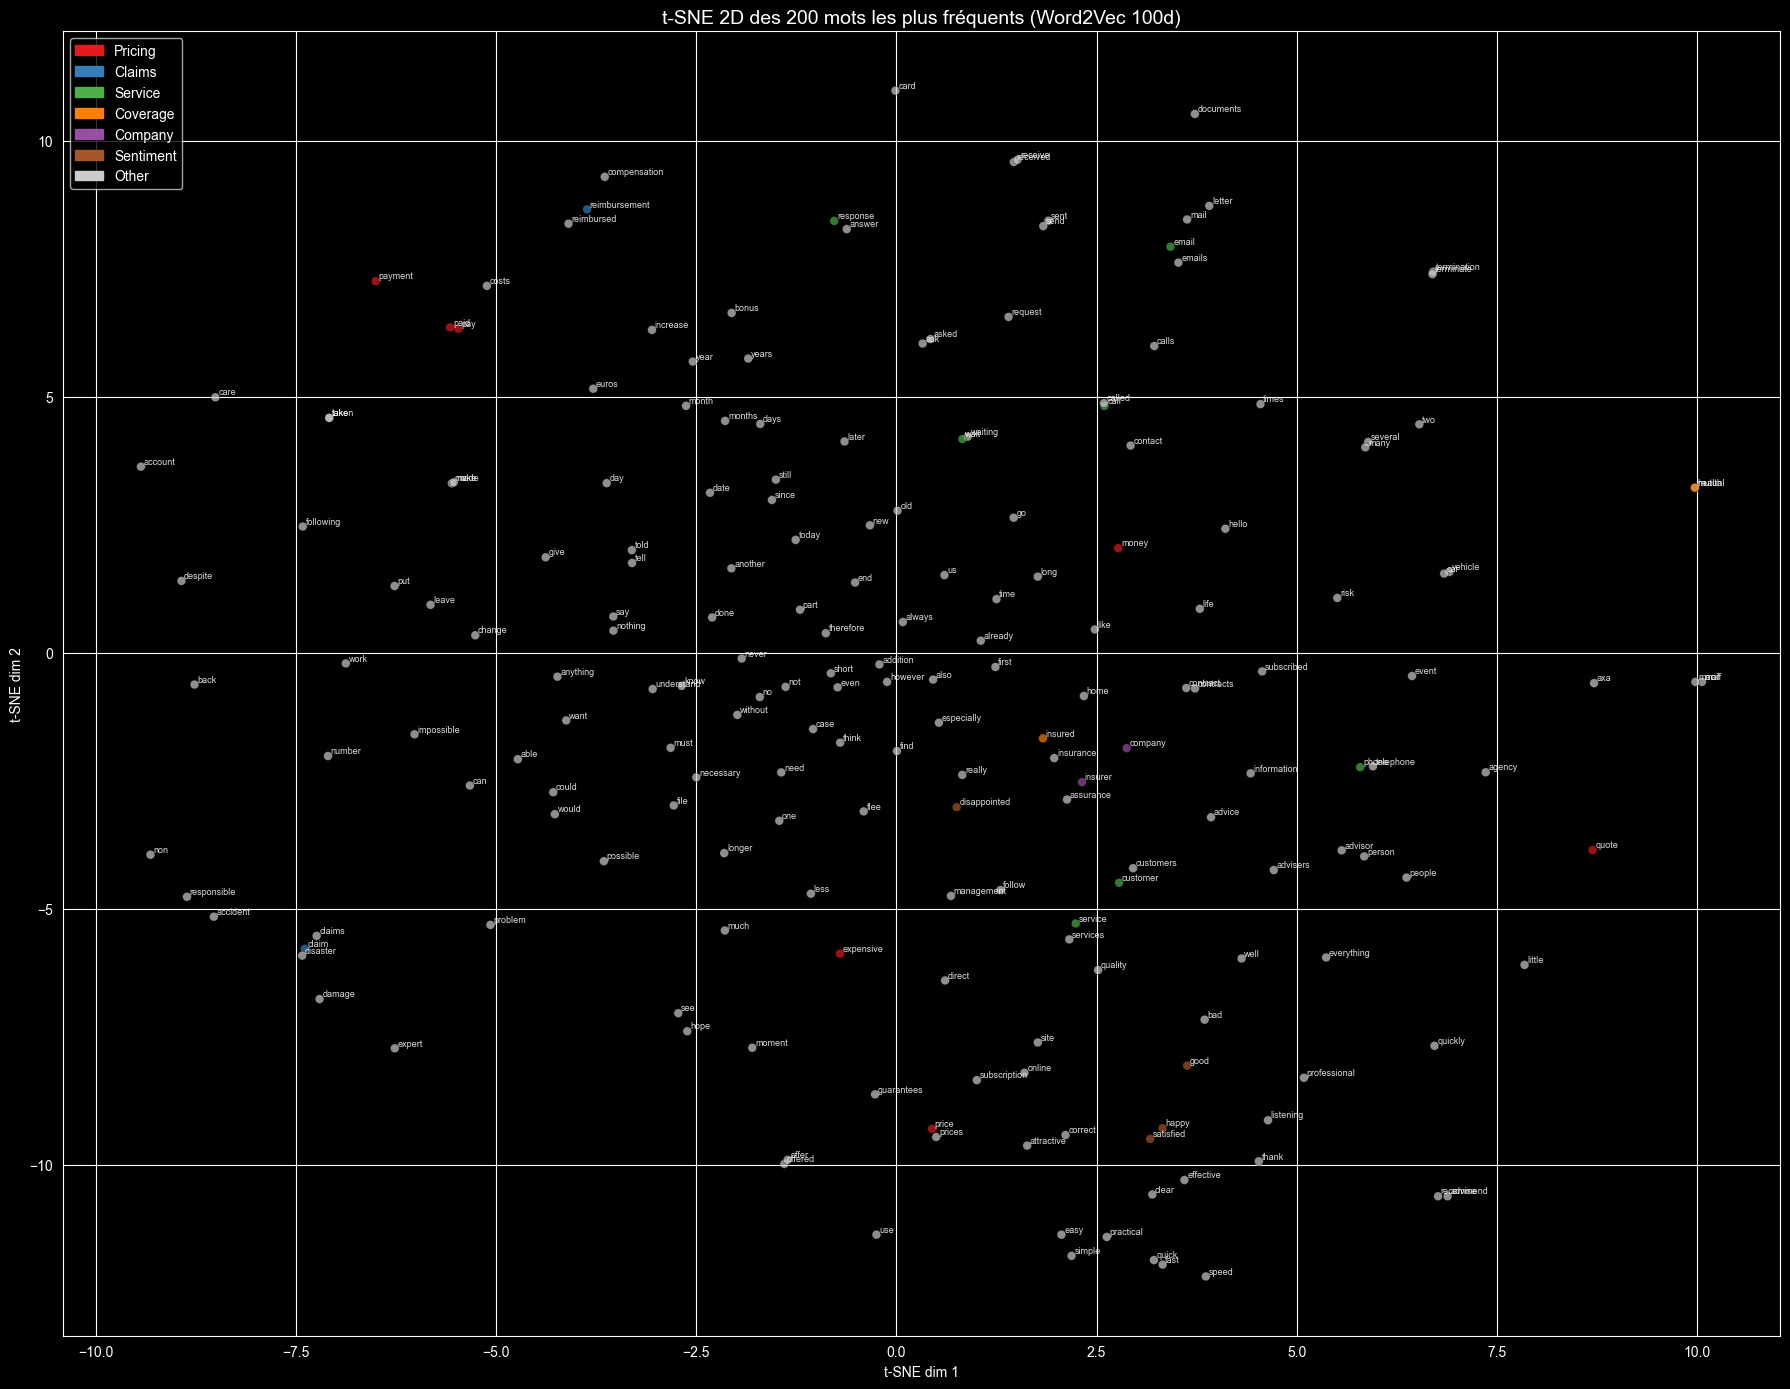

Figure sauvegardée : ../models/tsne_word2vec.png


In [13]:
# Define semantic clusters
categories = {
    'pricing':       ['price', 'cost', 'expensive', 'cheap', 'rate', 'premium', 'fee', 'pay', 'payment',
                      'paid', 'money', 'dollar', 'charge', 'charged', 'affordable', 'discount', 'quote'],
    'claims':        ['claim', 'denied', 'denial', 'reimbursement', 'reimburse', 'filed', 'filing',
                      'covered', 'coverage', 'deductible', 'payout', 'approved', 'rejected', 'process'],
    'service':       ['service', 'customer', 'support', 'agent', 'representative', 'helpful', 'rude',
                      'response', 'call', 'phone', 'email', 'wait', 'hold', 'staff', 'team', 'spoke'],
    'coverage':      ['coverage', 'policy', 'plan', 'benefit', 'cover', 'insured', 'deductible',
                      'limit', 'network', 'provider', 'hospital', 'doctor', 'medical', 'health'],
    'company':       ['geico', 'allstate', 'progressive', 'statefarm', 'nationwide', 'aetna', 'cigna',
                      'humana', 'united', 'anthem', 'company', 'insurer', 'carrier', 'broker'],
    'sentiment':     ['good', 'great', 'excellent', 'terrible', 'awful', 'worst', 'best', 'happy',
                      'satisfied', 'disappointed', 'frustrated', 'pleased', 'amazing', 'horrible'],
}

color_map = {
    'pricing':   '#e41a1c',
    'claims':    '#377eb8',
    'service':   '#4daf4a',
    'coverage':  '#ff7f00',
    'company':   '#984ea3',
    'sentiment': '#a65628',
    'other':     '#cccccc',
}

def get_category(word):
    for cat, words in categories.items():
        if word in words:
            return cat
    return 'other'

word_categories = [get_category(w) for w in top_words]
point_colors = [color_map[c] for c in word_categories]

# Plot
fig, ax = plt.subplots(figsize=(18, 14))
ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=point_colors, alpha=0.7, s=40, linewidths=0.3, edgecolors='k')

# Annotate all words
for i, word in enumerate(top_words):
    ax.annotate(
        word,
        xy=(tsne_coords[i, 0], tsne_coords[i, 1]),
        fontsize=6.5,
        alpha=0.85,
        xytext=(2, 2),
        textcoords='offset points'
    )

# Legend
legend_patches = [mpatches.Patch(color=color_map[cat], label=cat.capitalize()) for cat in color_map]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10, framealpha=0.8)

ax.set_title('t-SNE 2D des 200 mots les plus fréquents (Word2Vec 100d)', fontsize=14)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('../models/tsne_word2vec.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : ../models/tsne_word2vec.png')

## 4.6 Export TensorBoard Projector

Exportation des embeddings Word2Vec au format TSV pour TensorBoard Embedding Projector.

In [14]:
tb_dir = '../models/tensorboard_logs/embeddings'
os.makedirs(tb_dir, exist_ok=True)

vectors_path  = os.path.join(tb_dir, 'vectors.tsv')
metadata_path = os.path.join(tb_dir, 'metadata.tsv')

# Export all words in vocabulary (up to 5000 for TensorBoard performance)
export_words = w2v_model.wv.index_to_key[:5000]

# vectors.tsv  - one vector per line, tab-separated values
with open(vectors_path, 'w', encoding='utf-8') as fv:
    for word in export_words:
        vec = w2v_model.wv[word]
        fv.write('\t'.join(str(x) for x in vec) + '\n')

# metadata.tsv - one label per line (no header for compatibility)
with open(metadata_path, 'w', encoding='utf-8') as fm:
    for word in export_words:
        fm.write(word + '\n')

print(f'{len(export_words)} mots exportés.')
print(f'  Vecteurs  : {vectors_path}')
print(f'  Métadonnées : {metadata_path}')

5000 mots exportés.
  Vecteurs  : ../models/tensorboard_logs/embeddings/vectors.tsv
  Métadonnées : ../models/tensorboard_logs/embeddings/metadata.tsv


In [15]:
# Optional: TensorFlow SummaryWriter approach
try:
    import tensorflow as tf
    from tensorboard.plugins import projector

    log_dir = '../models/tensorboard_logs'

    # Build embedding variable
    emb_array = np.array([w2v_model.wv[w] for w in export_words], dtype=np.float32)
    weights = tf.Variable(emb_array, trainable=False, name='word_embeddings')

    # Checkpoint
    ckpt = tf.train.Checkpoint(embedding=weights)
    ckpt.save(os.path.join(log_dir, 'embedding.ckpt'))

    # Projector config
    config = projector.ProjectorConfig()
    embedding = config.embeddings.add()
    embedding.tensor_name = 'embedding/.ATTRIBUTES/VARIABLE_VALUE'
    embedding.metadata_path = 'embeddings/metadata.tsv'
    projector.visualize_embeddings(log_dir, config)

    print('TensorFlow SummaryWriter export OK')
except ImportError:
    print('TensorFlow non disponible — export TSV manuel déjà réalisé ci-dessus.')
except Exception as e:
    print(f'TF export échoué : {e} — export TSV manuel déjà réalisé ci-dessus.')

print()
print('=== Pour lancer TensorBoard ===')
print('  tensorboard --logdir=../models/tensorboard_logs')
print('Puis ouvrir http://localhost:6006 et cliquer sur l\'onglet "PROJECTOR"')
print('Charger vectors.tsv et metadata.tsv manuellement si nécessaire.')

TensorFlow SummaryWriter export OK

=== Pour lancer TensorBoard ===
  tensorboard --logdir=../models/tensorboard_logs
Puis ouvrir http://localhost:6006 et cliquer sur l'onglet "PROJECTOR"
Charger vectors.tsv et metadata.tsv manuellement si nécessaire.


## 4.7 Semantic Search avec FAISS (bonus)

Construction d'un index FAISS `IndexFlatL2` sur les vecteurs Word2Vec pour une recherche par similarité rapide.

In [16]:
try:
    import faiss

    # Build matrix of all word vectors
    all_words  = w2v_model.wv.index_to_key
    all_vecs   = np.array([w2v_model.wv[w] for w in all_words], dtype=np.float32)
    dim        = all_vecs.shape[1]

    # Build flat L2 index
    index_word = faiss.IndexFlatL2(dim)
    index_word.add(all_vecs)
    print(f'Index FAISS (Word2Vec) : {index_word.ntotal} vecteurs, dim={dim}')

    def semantic_search(query_word: str, top_k: int = 10):
        """Return top_k most similar words to query_word using FAISS L2 index."""
        if query_word not in w2v_model.wv:
            print(f"'{query_word}' absent du vocabulaire.")
            return []
        query_vec = np.array([w2v_model.wv[query_word]], dtype=np.float32)
        distances, indices = index_word.search(query_vec, top_k + 1)  # +1 to skip the word itself
        results = []
        for dist, idx in zip(distances[0], indices[0]):
            word = all_words[idx]
            if word != query_word:
                results.append((word, float(dist)))
        return results[:top_k]

    # Test searches
    test_queries = ['expensive', 'helpful', 'denied', 'easy']
    for q in test_queries:
        results = semantic_search(q, top_k=10)
        if results:
            res_str = ', '.join([f'{w} ({d:.3f})' for w, d in results])
            print(f"\nFAISS search '{q}': {res_str}")

except ImportError:
    print('FAISS non installé. Fallback avec Gensim most_similar.')

    def semantic_search(query_word: str, top_k: int = 10):
        if query_word not in w2v_model.wv:
            print(f"'{query_word}' absent du vocabulaire.")
            return []
        return w2v_model.wv.most_similar(query_word, topn=top_k)

    test_queries = ['expensive', 'helpful', 'denied', 'easy']
    for q in test_queries:
        results = semantic_search(q, top_k=10)
        if results:
            res_str = ', '.join([f'{w} ({s:.3f})' for w, s in results])
            print(f"\nGensim search '{q}': {res_str}")

FAISS non installé. Fallback avec Gensim most_similar.

Gensim search 'expensive': cheaper (0.758), high (0.713), negligible (0.711), dear (0.687), excessive (0.674), prospected (0.669), lower (0.665), cheapest (0.660), hurts (0.647), regrettable (0.645)

Gensim search 'helpful': smiling (0.851), welcoming (0.849), rali (0.844), diallo (0.838), receptive (0.836), pedagogue (0.835), jovial (0.833), benevolent (0.832), sympathetic (0.832), fairouz (0.827)

Gensim search 'denied': firmly (0.821), images (0.815), denounces (0.797), separated (0.796), triangle (0.795), gender (0.794), algorithm (0.793), drawn (0.793), perception (0.791), deferred (0.791)

Gensim search 'easy': ergonomic (0.798), fluid (0.792), intuitive (0.791), interface (0.791), facilitating (0.758), ease (0.758), constructed (0.744), navigation (0.741), guidance (0.737), budgets (0.730)


## 4.8 Semantic Search avec Sentence Transformers (bonus)

Encodage des avis avec `all-MiniLM-L6-v2` et recherche sémantique sur les phrases via FAISS.

In [17]:
try:
    from sentence_transformers import SentenceTransformer
    sbert_available = True
    print('sentence-transformers disponible.')
except ImportError:
    sbert_available = False
    print('sentence-transformers non installé. Section 4.8 ignorée.')
    print('Pour l\'installer : pip install sentence-transformers')

sentence-transformers disponible.


In [18]:
if sbert_available:
    try:
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
        print('Modèle all-MiniLM-L6-v2 chargé.')

        # Sample 1000 reviews
        sample_size = min(1000, len(df))
        sample_reviews = df['review_clean'].sample(sample_size, random_state=42).tolist()
        sample_reviews = [str(r) for r in sample_reviews]

        print(f'Encodage de {sample_size} avis...')
        sentence_embeddings = sbert_model.encode(
            sample_reviews,
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True
        )
        print(f'Shape embeddings : {sentence_embeddings.shape}')

    except Exception as e:
        sbert_available = False
        print(f'Erreur lors du chargement/encodage SBERT : {e}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modèle all-MiniLM-L6-v2 chargé.
Encodage de 1000 avis...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Shape embeddings : (1000, 384)


In [19]:
if sbert_available:
    try:
        import faiss
        faiss_available = True
    except ImportError:
        faiss_available = False
        print('FAISS non disponible. Fallback avec numpy pour la recherche.')

    sbert_dim = sentence_embeddings.shape[1]

    if faiss_available:
        # Normalize for cosine similarity (IndexFlatIP after normalization = cosine)
        emb_norm = sentence_embeddings.copy().astype(np.float32)
        faiss.normalize_L2(emb_norm)
        sbert_index = faiss.IndexFlatIP(sbert_dim)
        sbert_index.add(emb_norm)
        print(f'Index FAISS (SBERT) : {sbert_index.ntotal} vecteurs, dim={sbert_dim}')

        def search_reviews(query: str, top_k: int = 5):
            q_emb = sbert_model.encode([query], convert_to_numpy=True).astype(np.float32)
            faiss.normalize_L2(q_emb)
            scores, indices = sbert_index.search(q_emb, top_k)
            print(f"\n=== Recherche : '{query}' ===")
            for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), 1):
                review_text = sample_reviews[idx][:120]
                print(f'  [{rank}] score={score:.4f} | {review_text}...')

    else:
        def search_reviews(query: str, top_k: int = 5):
            q_emb = sbert_model.encode([query], convert_to_numpy=True)
            # Cosine similarity via dot product on normalized vectors
            emb_n = sentence_embeddings / (np.linalg.norm(sentence_embeddings, axis=1, keepdims=True) + 1e-9)
            q_n   = q_emb / (np.linalg.norm(q_emb) + 1e-9)
            scores = emb_n @ q_n.T
            top_indices = np.argsort(scores[:, 0])[::-1][:top_k]
            print(f"\n=== Recherche : '{query}' ===")
            for rank, idx in enumerate(top_indices, 1):
                review_text = sample_reviews[idx][:120]
                print(f'  [{rank}] score={scores[idx, 0]:.4f} | {review_text}...')

    # Test queries
    test_queries_sbert = [
        'my claim was denied without explanation',
        'great customer service very helpful',
        'too expensive for the coverage provided',
        'easy to cancel my policy online',
        'waiting a long time for reimbursement',
    ]
    for q in test_queries_sbert:
        search_reviews(q, top_k=5)

FAISS non disponible. Fallback avec numpy pour la recherche.

=== Recherche : 'my claim was denied without explanation' ===
  [1] score=0.4913 | better not claim one member mutual...
  [2] score=0.4898 | thank nothing added always fast received opinion concerning claim regulation sent cordially nothing added...
  [3] score=0.4855 | not satisfied service no one given answers current claims terminated without valid reasons...
  [4] score=0.4808 | unhappy declared claim assured risks matmut not recognize claim several letters telephone calls interlocutors unpleasant...
  [5] score=0.4663 | unhappy insurance refused take charge water damage leak saur pipes big damage forced take care amount euros obliged go c...

=== Recherche : 'great customer service very helpful' ===
  [1] score=0.6146 | good serious contact customer service always competent good advice courtesy...
  [2] score=0.5820 | customer service excellent advisers responsive kind good advice well done thank quality reception...
 

In [20]:
if sbert_available:
    try:
        # Save sentence embeddings
        np.save('../models/sentence_embeddings.npy', sentence_embeddings)
        print('Embeddings sauvegardés : ../models/sentence_embeddings.npy')

        # Save FAISS index
        try:
            import faiss
            faiss.write_index(sbert_index, '../models/faiss_index.bin')
            print('Index FAISS sauvegardé : ../models/faiss_index.bin')
        except Exception as fe:
            print(f'FAISS index non sauvegardé : {fe}')

    except Exception as e:
        print(f'Erreur lors de la sauvegarde : {e}')
else:
    print('Section 4.8 ignorée (sentence-transformers non disponible).')

Embeddings sauvegardés : ../models/sentence_embeddings.npy
FAISS index non sauvegardé : No module named 'faiss'


## Récapitulatif

| Etape | Résultat |
|-------|----------|
| Word2Vec (Skip-Gram, 100d) | Entraîné sur le corpus, modèle sauvegardé |
| GloVe pré-entraîné | Chargé via gensim.downloader |
| Distances cosine/euclidienne | Tableau comparatif sur 10 paires |
| t-SNE 2D | Figure annotée sauvegardée (`tsne_word2vec.png`) |
| TensorBoard Projector | TSV exportés dans `tensorboard_logs/embeddings/` |
| FAISS (Word2Vec) | Recherche sémantique par mot |
| Sentence Transformers | Recherche sémantique sur 1000 avis |

**Lancer TensorBoard :**
```bash
tensorboard --logdir=../models/tensorboard_logs
```